In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the data
# Replace 'netflix_dataset.csv' with your actual filename if different
df = pd.read_csv('netflix_dataset.csv')

# 2. Set the 'Netflix' aesthetic
sns.set_style("white") # Clean background
netflix_colors = ["#E50914", "#221F1F", "#F5F5F1"] # Red, Black, White
sns.set_palette(sns.color_palette(netflix_colors))

# 3. Look at the first 5 rows
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [2]:
# Check where the mess is
print(df.isnull().sum())

# Ethical Cleaning: Instead of deleting, we categorise
df['director'] = df['director'].fillna('Unknown Director')
df['cast'] = df['cast'].fillna('Unknown Cast')
df['country'] = df['country'].fillna('Unknown Country')

# Dropping only the absolute essentials
# If we don't know the date_added, we can't tell the "Global Story," so we drop those few rows.
df.dropna(subset=['date_added', 'rating'], inplace=True)

print("Cleaning Complete! Remaining missing values:", df.isnull().sum().sum())

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64
Cleaning Complete! Remaining missing values: 3


In [3]:
# Convert to datetime format
df['date_added'] = pd.to_datetime(df['date_added'].str.strip())

# Create a new column just for the Year
df['year_added'] = df['date_added'].dt.year

# Let's see the new column
df[['title', 'date_added', 'year_added']].head()

,title,date_added,year_added
0,Dick Johnson Is Dead,2021-09-25,2021
1,Blood & Water,2021-09-24,2021
2,Ganglands,2021-09-24,2021
3,Jailbirds New Orleans,2021-09-24,2021
4,Kota Factory,2021-09-24,2021


In [4]:
# This will show you the 'Data Type' of your columns
print(df['date_added'].dtype)

datetime64[us]


In [5]:
# Create a summarised table
# We group by 'year_added' and 'type', then count the IDs
content_growth = df.groupby(['year_added', 'type'])['show_id'].count().reset_index()

# Rename the column for clarity
content_growth.columns = ['Year', 'Type', 'Count']

# Let's see the first few rows of our new summary
content_growth.head()

,Year,Type,Count
0,2008,Movie,1
1,2008,TV Show,1
2,2009,Movie,2
3,2010,Movie,1
4,2011,Movie,13


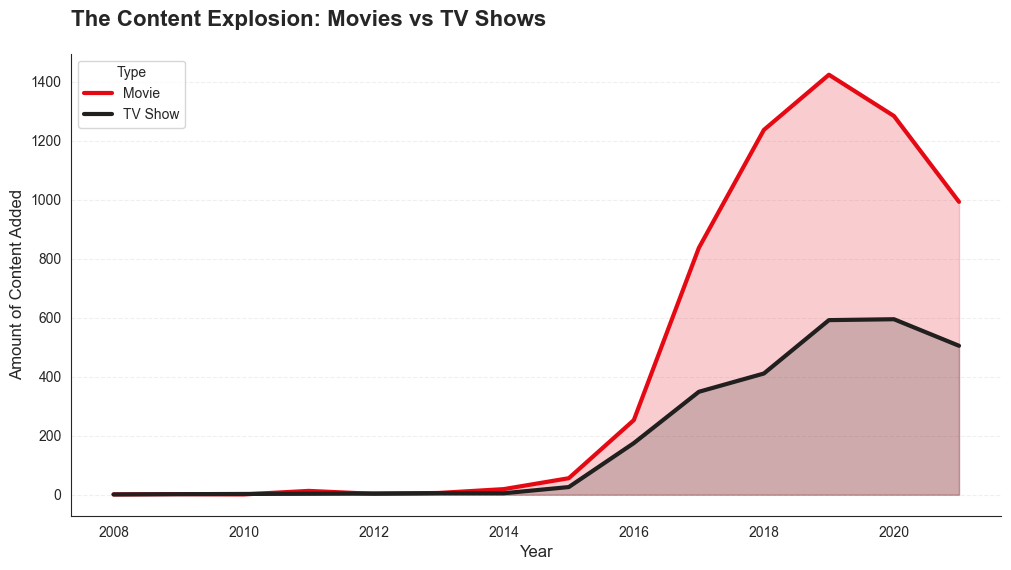

In [6]:
plt.figure(figsize=(12, 6))

# Plotting the data
sns.lineplot(data=content_growth, x='Year', y='Count', hue='Type', palette=['#E50914', '#221F1F'], linewidth=3)

# Filling the area under the lines for a professional look
plt.fill_between(content_growth[content_growth['Type'] == 'Movie']['Year'], 
                 content_growth[content_growth['Type'] == 'Movie']['Count'], color="#E50914", alpha=0.2)
plt.fill_between(content_growth[content_growth['Type'] == 'TV Show']['Year'], 
                 content_growth[content_growth['Type'] == 'TV Show']['Count'], color="#221F1F", alpha=0.2)

# Adding a professional "Netflix" touch
plt.title('The Content Explosion: Movies vs TV Shows', fontsize=16, fontweight='bold', loc='left', pad=20)
plt.ylabel('Amount of Content Added', fontsize=12)
plt.xlabel('Year', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.3)
sns.despine() # Removes the top and right borders for a modern look

plt.show()

In [ ]:
"""This chart visualizes the 'Pivot Point' of Netflix. We can observe that while Movie additions grew steadily, 
TV Show additions began to accelerate significantly after 2016. This aligns with Netflix's global strategy to 
capture 'Watch Time' through episodic content, which keeps subscribers on the platform longer than one-off films."""

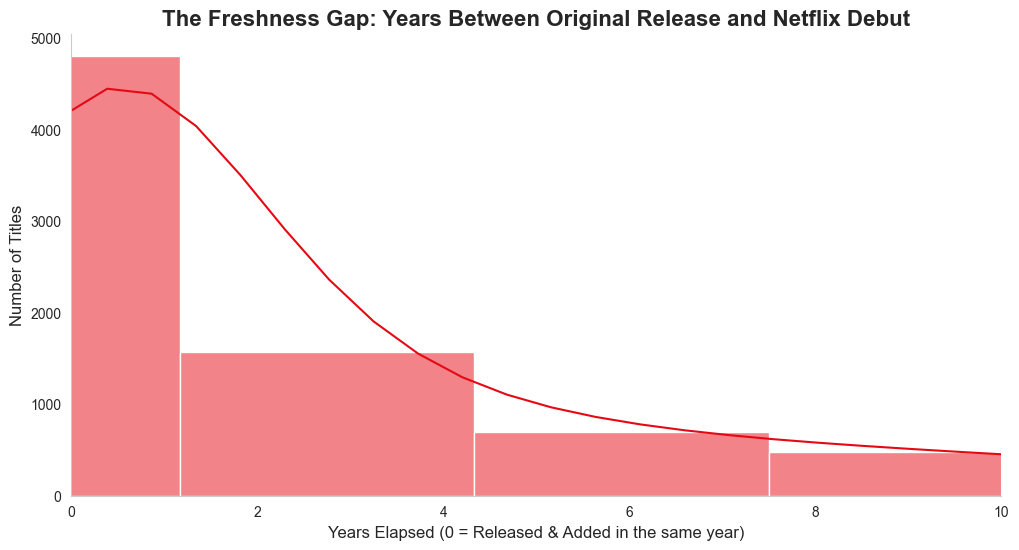

In [38]:
# 1. Ensure date_added is datetime and extract the year
if not pd.api.types.is_datetime64_any_dtype(df['date_added']):
    df['date_added'] = pd.to_datetime(df['date_added'].str.strip(), errors='coerce')

df['year_added'] = df['date_added'].dt.year

# 2. Calculate the "Freshness Gap"
# We only look at content added from 2015 onwards to see the modern strategy
df_fresh = df[df['year_added'] >= 2015].copy()
df_fresh['year_gap'] = df_fresh['year_added'] - df_fresh['release_year']

# 3. Visualisation: The Gap Distribution
plt.figure(figsize=(12, 6))

# We limit the x-axis to a 10-year gap to focus on "Fresh" vs "Recent"
sns.histplot(df_fresh['year_gap'], bins=30, kde=True, color='#e50914')

plt.title('The Freshness Gap: Years Between Original Release and Netflix Debut', fontsize=16, fontweight='bold')
plt.xlabel('Years Elapsed (0 = Released & Added in the same year)', fontsize=12)
plt.ylabel('Number of Titles', fontsize=12)
plt.xlim(0, 10) # Focus on the last decade
sns.despine()
plt.show()

In [8]:
# 1. Create a copy so we don't ruin our main dataframe
df_countries = df.copy()

# 2. Split the 'country' string into a list
# Example: "USA, India" becomes ["USA", "India"]
df_countries['country'] = df_countries['country'].str.split(', ')

# 3. The "Explode" magic
# This turns one row with a list into multiple rows with single countries
df_countries = df_countries.explode('country')

# 4. Clean up any accidental spaces
df_countries['country'] = df_countries['country'].str.strip()

# Let's see the top 10 countries now
top_10_countries = df_countries['country'].value_counts().head(10)
print(top_10_countries)

country
United States      3683
India              1046
Unknown Country     829
United Kingdom      803
Canada              445
France              393
Japan               316
Spain               232
South Korea         231
Germany             226
Name: count, dtype: int64


C:\Users\Gaming 15\AppData\Local\Temp\ipykernel_17380\1556742485.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=top_10_countries.values, y=top_10_countries.index, palette='Reds_r')


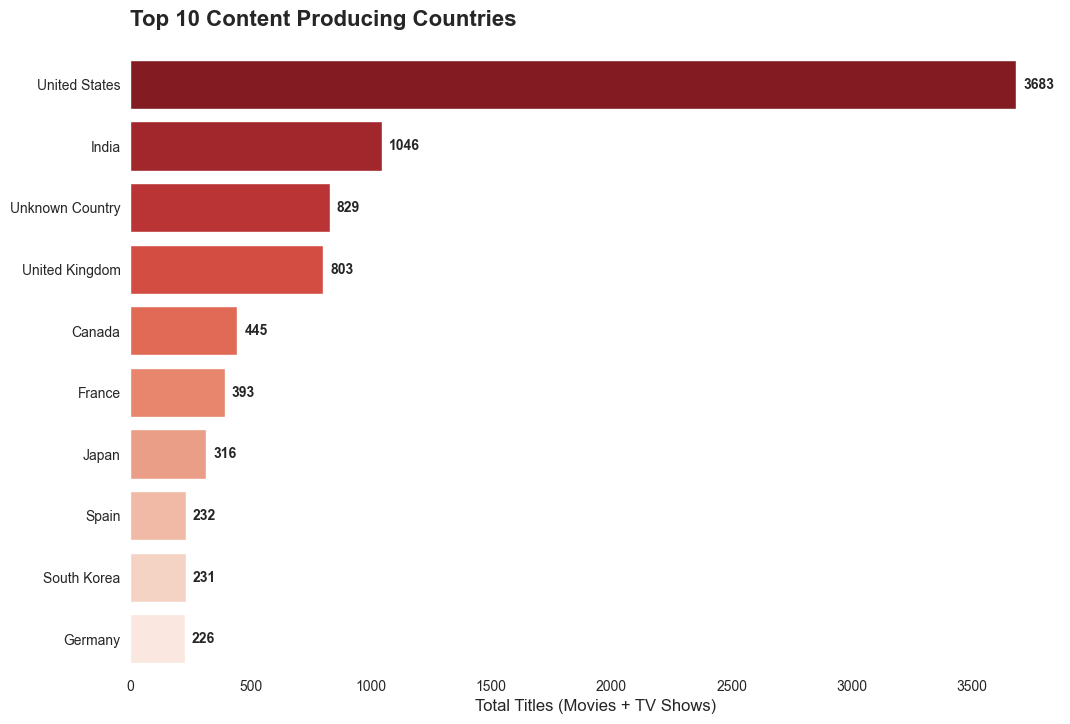

In [9]:
plt.figure(figsize=(12, 8))

# Create the plot
ax = sns.barplot(x=top_10_countries.values, y=top_10_countries.index, palette='Reds_r')

# Add the counts at the end of each bar for a "Pro" look
for i in ax.containers:
    ax.bar_label(i, padding=5, fontsize=10, fontweight='bold')

# Styling
plt.title('Top 10 Content Producing Countries', fontsize=16, fontweight='bold', loc='left', pad=20)
plt.xlabel('Total Titles (Movies + TV Shows)', fontsize=12)
plt.ylabel('') # Hiding 'country' label as names are obvious
sns.despine(left=True, bottom=True) # Makes it look very clean

plt.show()

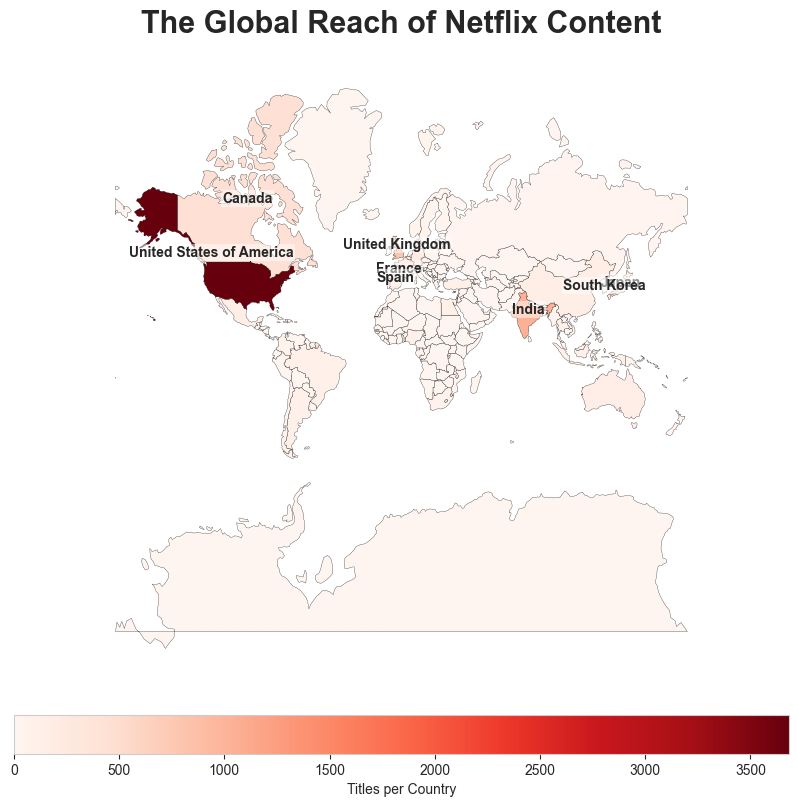

In [24]:
import geopandas as gpd
import matplotlib.pyplot as plt

# 1. Load the map shapes from a reliable web source (avoids the local dataset error)
world = gpd.read_file("https://raw.githubusercontent.com/python-visualization/folium/master/examples/data/world-countries.json")

# 2. Data Alignment: Match 'United States' to the map's naming convention
# We use the map_data we created earlier from df_countries
map_data['country'] = map_data['country'].replace({'United States': 'United States of America'})

# 3. Merge the shapes with our Netflix counts
merged = world.merge(map_data, left_on='name', right_on='country', how='left').fillna(0)

# Convert the map to a 'flat' projection (Web Mercator)
merged = merged.to_crs(epsg=3857)

# 4. Create the Visual
fig, ax = plt.subplots(1, 1, figsize=(20, 10))

# Plot the base map with the Netflix Red theme
merged.plot(column='count', 
            ax=ax, 
            legend=True, 
            cmap='Reds', 
            edgecolor='black', 
            linewidth=0.2,
            legend_kwds={'label': "Titles per Country", 'orientation': "horizontal", 'pad': 0.05, 'shrink': 0.5})

# 5. ADDING LABELS: We label the Top Producers to avoid clutter
# We calculate the center of each country to place the text correctly
top_producers = merged.nlargest(8, 'count') 

for x, y, label in zip(top_producers.geometry.centroid.x, top_producers.geometry.centroid.y, top_producers['name']):
    ax.text(x, y, label, fontsize=10, fontweight='bold', ha='center', 
            bbox=dict(facecolor='white', alpha=0.5, edgecolor='none', pad=1))

plt.title('The Global Reach of Netflix Content', fontsize=22, fontweight='bold', pad=20)
ax.axis('off')
plt.show()

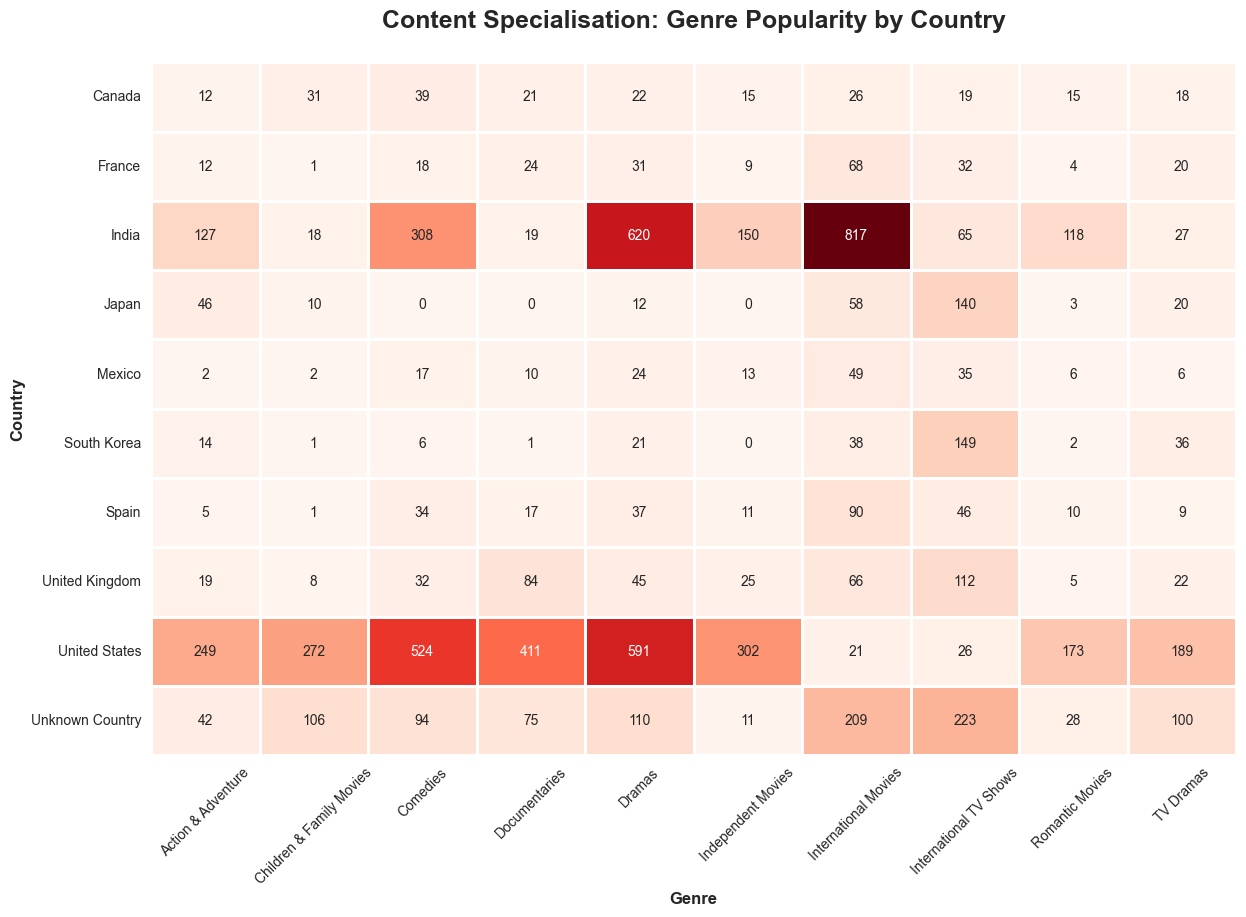

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Create the 'exploded' genre list (The step we missed!)
# Netflix often lists multiple genres (e.g., 'Action, Sci-Fi'). 
# We split them so we can count every genre properly.
df_genres = df.copy()
df_genres['listed_in'] = df_genres['listed_in'].str.split(', ')
df_genres = df_genres.explode('listed_in')

# 2. Identify the Top 10 Countries and Top 10 Genres 
# This ensures the heatmap is clean and not cluttered
top_10_countries = df['country'].value_counts().head(10).index
top_10_genres = df_genres['listed_in'].value_counts().head(10).index

# 3. Create a Subset and Pivot Table for the Heatmap
heatmap_data = df_genres[df_genres['country'].isin(top_10_countries) & 
                        df_genres['listed_in'].isin(top_10_genres)]
pivot = heatmap_data.groupby(['country', 'listed_in']).size().unstack().fillna(0)

# 4. Final Visualisation
plt.figure(figsize=(14, 9))
# 'fmt=.0f' is the "secret" to removing the scientific notation (7e+02)
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='Reds', linewidths=1, cbar=False)

plt.title('Content Specialisation: Genre Popularity by Country', fontsize=18, fontweight='bold', pad=25)
plt.ylabel('Country', fontsize=12, fontweight='bold')
plt.xlabel('Genre', fontsize=12, fontweight='bold')
plt.xticks(rotation=45)
plt.show()

# NEXT QUESTION: When is the best time to release content? 
# Does Netflix release more shows in the Winter or Summer to maximise viewership?

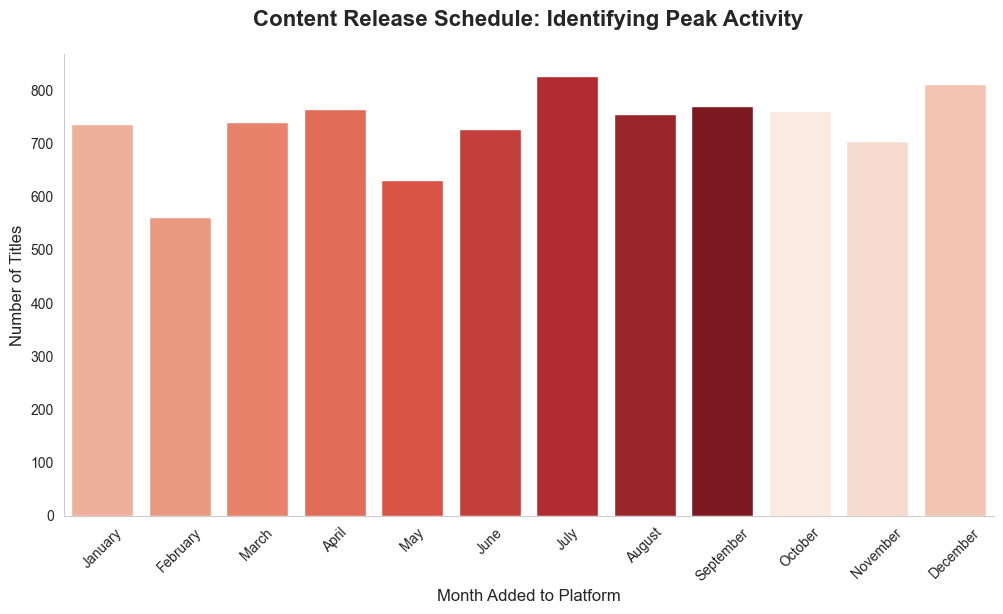

In [29]:
# 1. Final check to ensure date_added is correctly formatted
if not pd.api.types.is_datetime64_any_dtype(df['date_added']):
    df['date_added'] = pd.to_datetime(df['date_added'].str.strip(), errors='coerce')

# 2. Extracting month and defining chronological order
df['month_added'] = df['date_added'].dt.month_name()
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 
               'July', 'August', 'September', 'October', 'November', 'December']

# 3. Visualisation with the Hue Fix (Removes the FutureWarning)
plt.figure(figsize=(12, 6))
sns.countplot(data=df, 
              x='month_added', 
              order=month_order, 
              hue='month_added', # Assigning x to hue removes the warning
              palette='Reds_r', 
              legend=False)      # Hiding the legend as it's redundant here

plt.title('Content Release Schedule: Identifying Peak Activity', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Month Added to Platform', fontsize=12)
plt.ylabel('Number of Titles', fontsize=12)
plt.xticks(rotation=45)
sns.despine()
plt.show()

# NEXT QUESTION: What is the distribution of 'Ratings' (e.g., TV-MA vs PG)? 
# Is the library becoming increasingly mature as the platform grows?

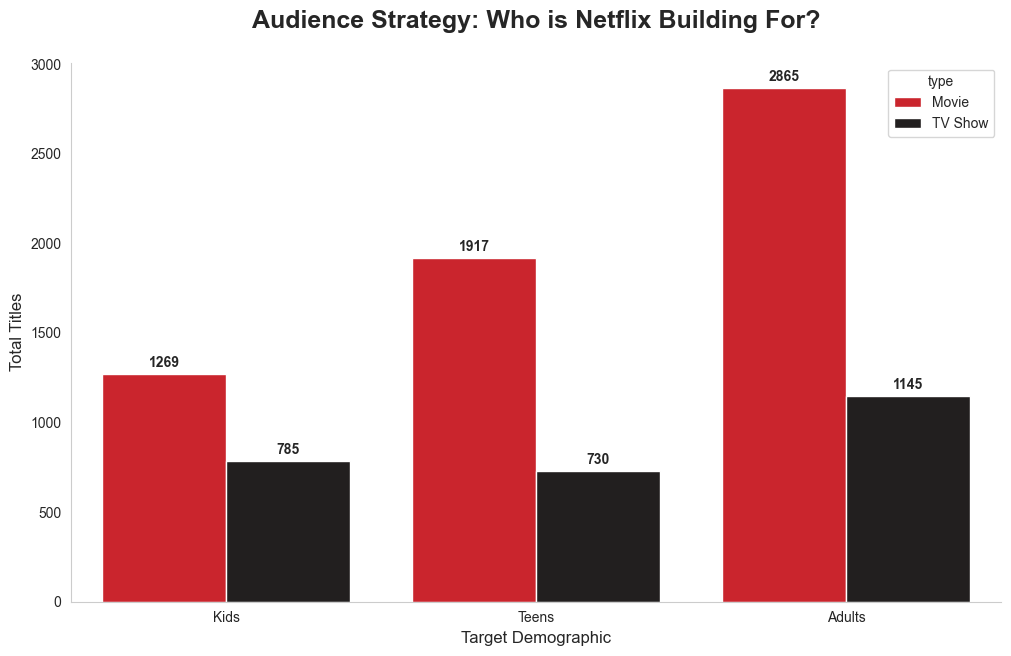

In [31]:
# 1. Define the Mapping for Age Groups
# This simplifies the complex rating system into three clear business categories
ratings_map = {
    'TV-MA': 'Adults', 'R': 'Adults', 'PG-13': 'Teens', 
    'TV-14': 'Teens', 'TV-PG': 'Kids', 'TV-G': 'Kids', 
    'TV-Y': 'Kids', 'TV-Y7': 'Kids', 'PG': 'Kids', 
    'G': 'Kids', 'NC-17': 'Adults', 'TV-Y7-FV': 'Kids', 'UR': 'Adults'
}

# 2. Apply the mapping
df['target_audience'] = df['rating'].map(ratings_map)

# 3. Visualisation: Distribution of Audience Groups
plt.figure(figsize=(12, 7))
# Setting a specific order so the "story" flows from youngest to oldest
audience_order = ['Kids', 'Teens', 'Adults']

ax = sns.countplot(data=df, 
                   x='target_audience', 
                   order=audience_order, 
                   hue='type', 
                   palette=['#e50914', '#221f1f'])

# Adding labels on top of bars for clarity
for i in ax.containers:
    ax.bar_label(i, padding=3, fontsize=10, fontweight='bold')

plt.title('Audience Strategy: Who is Netflix Building For?', fontsize=18, fontweight='bold', pad=25)
plt.xlabel('Target Demographic', fontsize=12)
plt.ylabel('Total Titles', fontsize=12)
sns.despine()
plt.show()

# NEXT QUESTION: Who are the "Top 10 Directors" driving this content? 
# Do certain directors specialise in the 'Adults' or 'Kids' segments?

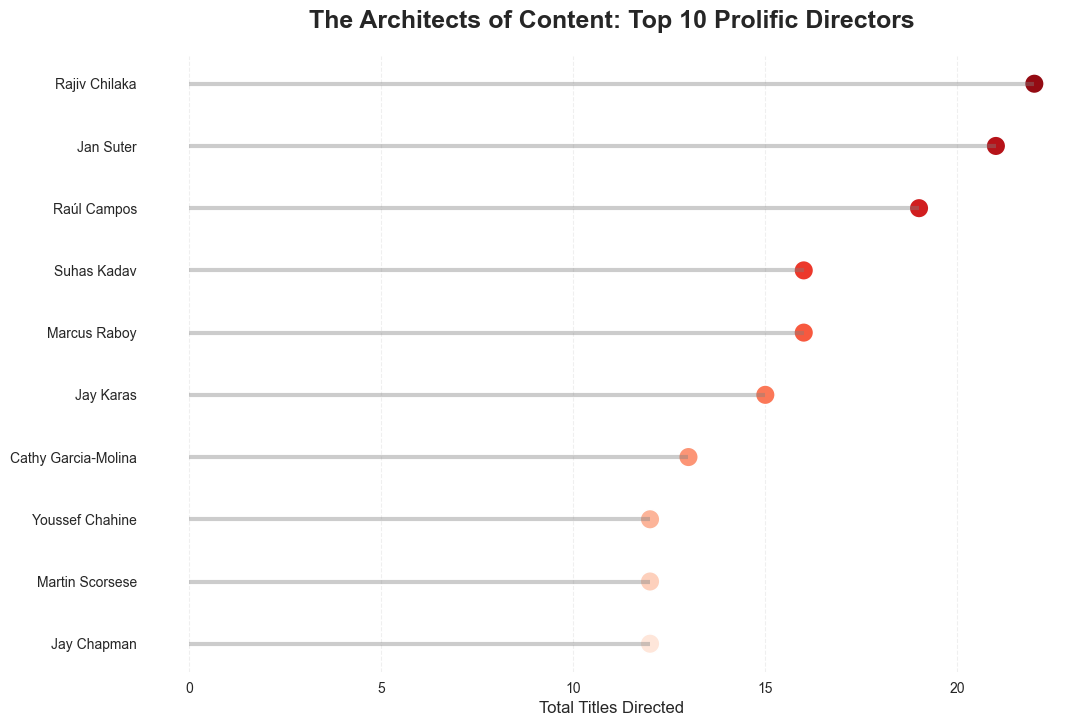

In [33]:
# 1. Clean and Explode Directors (Handling multiple directors per title)
df_dir = df[df['director'] != 'Unknown Director'].copy()
df_dir['director'] = df_dir['director'].str.split(', ')
df_dir = df_dir.explode('director')

# 2. Get Top 10 Directors
top_directors = df_dir['director'].value_counts().head(10).reset_index()
top_directors.columns = ['director', 'count']

# 3. Create a Lollipop Chart (A stylish alternative to Bar Charts)
plt.figure(figsize=(12, 8))

# Create the "sticks" of the lollipops
plt.hlines(y=top_directors['director'], xmin=0, xmax=top_directors['count'], 
           color='grey', alpha=0.4, linewidth=3)

# Create the "heads" (the dots) and fix the 'hue' warning here
sns.scatterplot(data=top_directors, x='count', y='director', 
                hue='director', palette='Reds_r', s=200, legend=False)

# 4. Final Polish (British English)
plt.title('The Architects of Content: Top 10 Prolific Directors', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Total Titles Directed', fontsize=12)
plt.ylabel('')
sns.despine(left=True, bottom=True)
plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.show()

# NEXT STEP: The Word Cloud to visualise the thematic 'vibe' of Netflix descriptions.

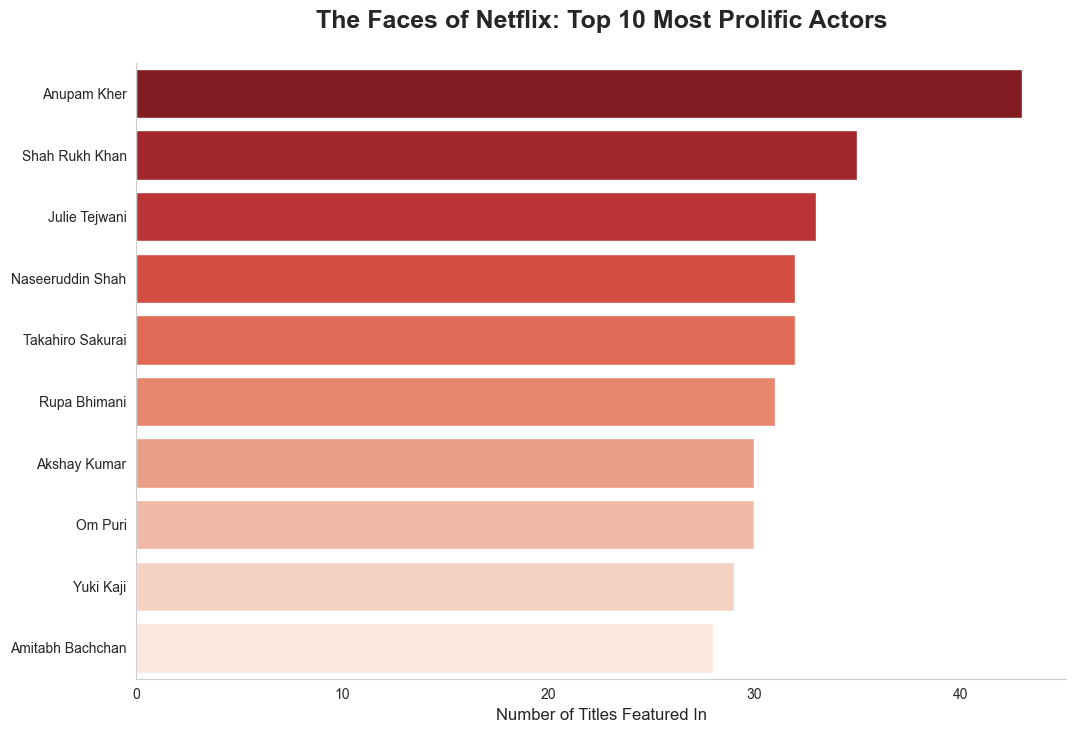

In [34]:
# 1. Clean and Explode the Cast (Handling multiple actors per title)
# We filter out 'Unknown Cast' to keep the data meaningful
df_cast = df[df['cast'] != 'Unknown Cast'].copy()
df_cast['cast'] = df_cast['cast'].str.split(', ')
df_cast = df_cast.explode('cast')

# 2. Get Top 10 Actors
top_actors = df_cast['cast'].value_counts().head(10).reset_index()
top_actors.columns = ['actor', 'count']

# 3. Visualisation (Using the 'hue' fix to prevent warnings)
plt.figure(figsize=(12, 8))
sns.barplot(data=top_actors, 
            x='count', 
            y='actor', 
            hue='actor',      # Explicitly mapping hue to the y-variable
            palette='Reds_r', 
            legend=False)     # Prevents an unnecessary legend box

# 4. Final Polish (British English)
plt.title('The Faces of Netflix: Top 10 Most Prolific Actors', fontsize=18, fontweight='bold', pad=25)
plt.xlabel('Number of Titles Featured In', fontsize=12)
plt.ylabel('') # Removing the label for a cleaner look
sns.despine()
plt.show()

# NEXT STEP: The Word Cloud to visualise the thematic 'vibe' of Netflix descriptions.

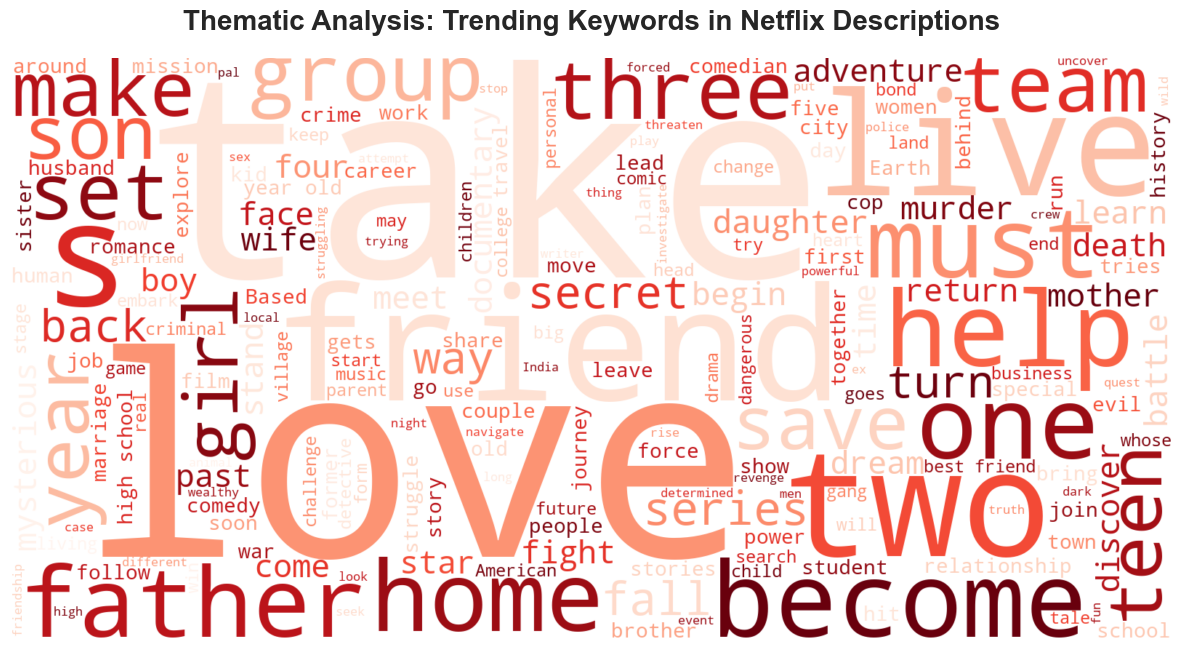

In [37]:
from wordcloud import WordCloud, STOPWORDS

# 1. Clean the text: Combine all descriptions into one long string
text = " ".join(desc for desc in df.description.dropna())

# 2. Refine the 'Stopwords': We remove boring words that don't tell a story
# We also remove "Netflix" and "Original" to see the actual plot themes
custom_stopwords = set(STOPWORDS)
custom_stopwords.update(["life", "family", "find", "finds", "man", "woman", "young", "new", "world"])

# 3. Generate the Visualisation
wordcloud = WordCloud(stopwords=custom_stopwords, 
                      background_color="white", 
                      colormap='Reds', # Keeping our Netflix Red theme
                      width=1600, 
                      height=800).generate(text)

# 4. Display
plt.figure(figsize=(15, 10))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off") # Hide the axes for a clean "Artistic" look
plt.title('Thematic Analysis: Trending Keywords in Netflix Descriptions', fontsize=20, fontweight='bold', pad=20)
plt.show()